Importing Libraries

In [334]:

# This line performs: import pandas as pd
import pandas as pd
# This line performs: import numpy as np
import numpy as np
# This line performs: import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
# This line performs: import seaborn as sns
import seaborn as sns

# This line performs: cmap = sns.diverging_palette(220, 10, as_cmap=True)  # blue-
cmap = sns.diverging_palette(220, 10, as_cmap=True)  # blue-to-red diverging palette

# This line performs: from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import LabelEncoder
# This line performs: from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler
# This line performs: from sklearn.decomposition import PCA
from sklearn.decomposition import PCA



Loading Dataset

In [335]:
# This line performs: r_df= pd.read_csv('C:\\Users\\harib\\Caro\\AI\\ReDi_Cust_Seg
r_df= pd.read_csv('C:\\Users\\harib\\Caro\\AI\\ReDi_Cust_Seg\\Data\\Raw_Data_CustSeg.csv')


Observing Data

In [336]:
# This line performs: print("Number of Data Points", len(r_df))
print("Number of Data Points", len(r_df))
# This line performs: print("Shape of DataSet", r_df.shape)
print("Shape of DataSet", r_df.shape)
# This line performs: r_df.head()
r_df.head()

Number of Data Points 2240
Shape of DataSet (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


About Dataset

In [337]:
# This line performs: r_df.info()
r_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [338]:
# This line performs: r_df.isna().sum()
r_df.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

"""
- Step:1 Income Column                                  - Missing Values                         - Drop
- Step:2 Dt_Customer Column                             - Type of Data is not in Date format
- Step:3 Education, Marital_Status(Categorical Columns) - Object 

"""

In [339]:
# Step-1 Remove missing inccome rows

# This line performs: r_df = r_df.dropna()
r_df = r_df.dropna()
# This line performs: print("Number of data points after dropping missing values",
print("Number of data points after dropping missing values", len(r_df))
# This line performs: print("Shape of DataSet after dropping missing values", r_df
print("Shape of DataSet after dropping missing values", r_df.shape)

Number of data points after dropping missing values 2216
Shape of DataSet after dropping missing values (2216, 29)


In [340]:
# Step-2 Dt_Customer Column - Changed type to Date time format

# This line performs: r_df["Dt_Customer"] = pd.to_datetime(r_df["Dt_Customer"], fo
r_df["Dt_Customer"] = pd.to_datetime(r_df["Dt_Customer"], format="%d-%m-%Y", errors='coerce')


In [341]:

# Gathering infor about data set - First enrollment date and last enrollment date
# This line performs: print("Newest Enrollment:", r_df["Dt_Customer"].max().date()
print("Newest Enrollment:", r_df["Dt_Customer"].max().date())
# This line performs: print("Oldest Enrollment:", r_df["Dt_Customer"].min().date()
print("Oldest Enrollment:", r_df["Dt_Customer"].min().date())

Newest Enrollment: 2014-06-29
Oldest Enrollment: 2012-07-30


In [342]:
# Extract date part
# This line performs: date = r_df["Dt_Customer"].dt.date
date = r_df["Dt_Customer"].dt.date

# Find the newest customer date
# This line performs: d1 = date.max()
d1 = date.max()

# Compute how long each customer has been with the company (in days)
# This line performs: r_df["Customer_Tenure"] = (date - d1).apply(lambda x: -x.day
r_df["Customer_Tenure"] = (date - d1).apply(lambda x: -x.days)  # negative timedelta converted to positive days

# Check
# This line performs: print(r_df[["ID", "Dt_Customer", "Customer_Tenure"]].head())
print(r_df[["ID", "Dt_Customer", "Customer_Tenure"]].head())


     ID Dt_Customer  Customer_Tenure
0  5524  2012-09-04              663
1  2174  2014-03-08              113
2  4141  2013-08-21              312
3  6182  2014-02-10              139
4  5324  2014-01-19              161


In [343]:
# Step-3  Categorical features - Education and Marital_Status - Understhanding

# Unique values observation

# This line performs: print("Total categories-Marital_Status:\n", r_df["Marital_St
print("Total categories-Marital_Status:\n", r_df["Marital_Status"].value_counts(), "\n")
# This line performs: print("Total categories-Education:\n", r_df["Education"].val
print("Total categories-Education:\n", r_df["Education"].value_counts())

Total categories-Marital_Status:
 Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64 

Total categories-Education:
 Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64


Feature Engineering

Step 1. Extract the "Age" of a customer from Year_birth
Step 2. Creating feature "Money_Spent" indicating the total amount spent categorywise by custmomer over the span of two years.
Step 3. Creating feature "Living_With" out of "Marital_Status" to extract the living situation of couples.
Step 4. Creating feature "Children" to indicate total children in a household that is, kids and teenagers.
Step 5. clarity of household, Creating feature indicating "Family_Size"
Step 6. Creating a feature "Is_Parent" to indicate parenthood status
Step 7. creating three categories in the "Education" by simplifying its value counts.
Dropping some of the redundant features

In [344]:

# Step 1 Age of customer today 

# This line performs: r_df["Age"] = 2025-r_df["Year_Birth"]
r_df["Age"] = 2025-r_df["Year_Birth"]

# Step 2 Total spendings on various items

# This line performs: spending_cols = ["MntWines", "MntFruits", "MntMeatProducts",
spending_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
# This line performs: r_df["Money_Spent"] = r_df[spending_cols].sum(axis=1)
r_df["Money_Spent"] = r_df[spending_cols].sum(axis=1)

# Step 3 Deriving living situation by marital status"Alone"

# This line performs: living_map = {
living_map = {
# This line performs: "Married": "Family",
    "Married": "Family",
# This line performs: "Together": "Family",
    "Together": "Family",
# This line performs: "Absurd": "Alone",
    "Absurd": "Alone",
# This line performs: "Widow": "Alone",
    "Widow": "Alone",
# This line performs: "YOLO": "Alone",
    "YOLO": "Alone",
# This line performs: "Divorced": "Alone",
    "Divorced": "Alone",
# This line performs: "Single": "Alone"
    "Single": "Alone"
# This line performs: }
}
# This line performs: r_df["Living_With"] = r_df["Marital_Status"].map(living_map)
r_df["Living_With"] = r_df["Marital_Status"].map(living_map)

# Step 4 Total children living in the household

# This line performs: r_df["Num_Children"]=r_df["Kidhome"]+r_df["Teenhome"]
r_df["Num_Children"]=r_df["Kidhome"]+r_df["Teenhome"]

#  Step 5 Total family size

# This line performs: r_df["Family_Size"] = r_df["Num_Children"] + r_df["Living_Wi
r_df["Family_Size"] = r_df["Num_Children"] + r_df["Living_With"].map({"Alone": 1, "Family": 2})

# Step 6 parenthood indicator

# This line performs: r_df["Is_Parent"] = (r_df["Num_Children"] > 0).astype(int)
r_df["Is_Parent"] = (r_df["Num_Children"] > 0).astype(int)

# Step 7 Education segmentation

# This line performs: education_map = {
education_map = {
# This line performs: "Basic": "Undergraduate",
    "Basic": "Undergraduate",
# This line performs: "2n Cycle": "Undergraduate",
    "2n Cycle": "Undergraduate",
# This line performs: "Graduation": "Graduate",
    "Graduation": "Graduate",
# This line performs: "Master": "Postgraduate",
    "Master": "Postgraduate",
# This line performs: "PhD": "Postgraduate"
    "PhD": "Postgraduate"
# This line performs: }
}
# This line performs: r_df["Education"] = r_df["Education"].map(education_map)
r_df["Education"] = r_df["Education"].map(education_map)

# Step 8 Renaming Products columns
# This line performs: rename_map = {
rename_map = {
# This line performs: "MntWines": "Wines",
    "MntWines": "Wines",
# This line performs: "MntFruits": "Fruits",
    "MntFruits": "Fruits",
# This line performs: "MntMeatProducts": "Meat",
    "MntMeatProducts": "Meat",
# This line performs: "MntFishProducts": "Fish",
    "MntFishProducts": "Fish",
# This line performs: "MntSweetProducts": "Sweets",
    "MntSweetProducts": "Sweets",
# This line performs: "MntGoldProds": "Gold"
    "MntGoldProds": "Gold"
# This line performs: }
}
# This line performs: r_df.rename(columns=rename_map, inplace=True)
r_df.rename(columns=rename_map, inplace=True)

# Step 9 Dropping some of the redundant columns

# This line performs: drop_cols = ["Marital_Status", "Dt_Customer", "Z_CostContact
drop_cols = ["Marital_Status", "Dt_Customer", "Z_CostContact", "Z_Revenue", "Year_Birth", "ID"]
# This line performs: r_df.drop(columns=drop_cols, inplace=True)
r_df.drop(columns=drop_cols, inplace=True)

Data Set - After Feature engineering

In [345]:
# This line performs: r_df.head(5)
r_df.head(5)

,Education,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweets,...,AcceptedCmp2,Complain,Response,Customer_Tenure,Age,Money_Spent,Living_With,Num_Children,Family_Size,Is_Parent
0,Graduate,58138.0,0,0,58,635,88,546,172,88,...,0,0,1,663,68,1617,Alone,0,1.0,0
1,Graduate,46344.0,1,1,38,11,1,6,2,1,...,0,0,0,113,71,27,Alone,2,3.0,1
2,Graduate,71613.0,0,0,26,426,49,127,111,21,...,0,0,0,312,60,776,Family,0,2.0,0
3,Graduate,26646.0,1,0,26,11,4,20,10,3,...,0,0,0,139,41,53,Family,1,3.0,1
4,Postgraduate,58293.0,1,0,94,173,43,118,46,27,...,0,0,0,161,44,422,Family,1,3.0,1


In [346]:
# This line performs: r_df.isna().sum()
r_df.isna().sum()

Education              0
Income                 0
Kidhome                0
Teenhome               0
Recency                0
Wines                  0
Fruits                 0
Meat                   0
Fish                   0
Sweets                 0
Gold                   0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Response               0
Customer_Tenure        0
Age                    0
Money_Spent            0
Living_With            3
Num_Children           0
Family_Size            3
Is_Parent              0
dtype: int64

In [347]:
# This line performs: r_df = r_df.dropna()
r_df = r_df.dropna()

# This line performs: r_df.isna().sum()
r_df.isna().sum()

Education              0
Income                 0
Kidhome                0
Teenhome               0
Recency                0
Wines                  0
Fruits                 0
Meat                   0
Fish                   0
Sweets                 0
Gold                   0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Response               0
Customer_Tenure        0
Age                    0
Money_Spent            0
Living_With            0
Num_Children           0
Family_Size            0
Is_Parent              0
dtype: int64

In [348]:
# This line performs: r_df.describe()
r_df.describe()

,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,...,AcceptedCmp1,AcceptedCmp2,Complain,Response,Customer_Tenure,Age,Money_Spent,Num_Children,Family_Size,Is_Parent
count,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,...,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000
mean,52258.717578,0.441030,0.505197,49.037958,305.254858,26.386353,167.186624,37.678265,27.056033,43.988251,...,0.064166,0.013556,0.009489,0.150023,353.745142,56.185269,607.550384,0.946227,2.592408,0.713963
std,25184.057306,0.536866,0.544241,28.955762,337.404773,39.812221,224.374666,54.777236,41.092831,51.845488,...,0.245104,0.115666,0.096972,0.357174,202.341761,11.984205,603.091467,0.748899,0.906165,0.452009
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,29.000000,5.000000,0.000000,1.000000,0.000000
25%,35322.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,180.000000,48.000000,69.000000,0.000000,2.000000,0.000000
50%,51390.000000,0.000000,0.000000,49.000000,175.000000,8.000000,68.000000,12.000000,8.000000,25.000000,...,0.000000,0.000000,0.000000,0.000000,356.000000,55.000000,397.000000,1.000000,3.000000,1.000000
75%,68627.000000,1.000000,1.000000,74.000000,505.000000,33.000000,233.000000,50.000000,33.000000,56.000000,...,0.000000,0.000000,0.000000,0.000000,529.000000,66.000000,1048.000000,1.000000,3.000000,1.000000
max,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,...,1.000000,1.000000,1.000000,1.000000,699.000000,132.000000,2525.000000,3.000000,5.000000,1.000000


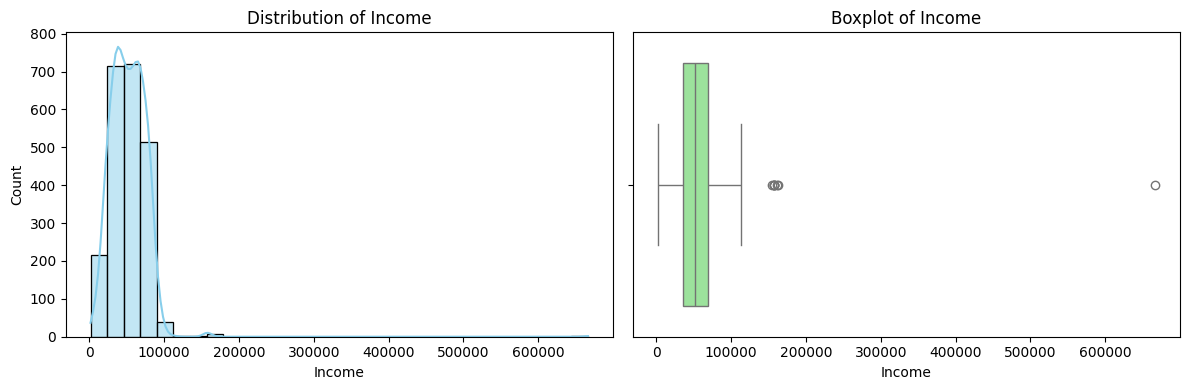

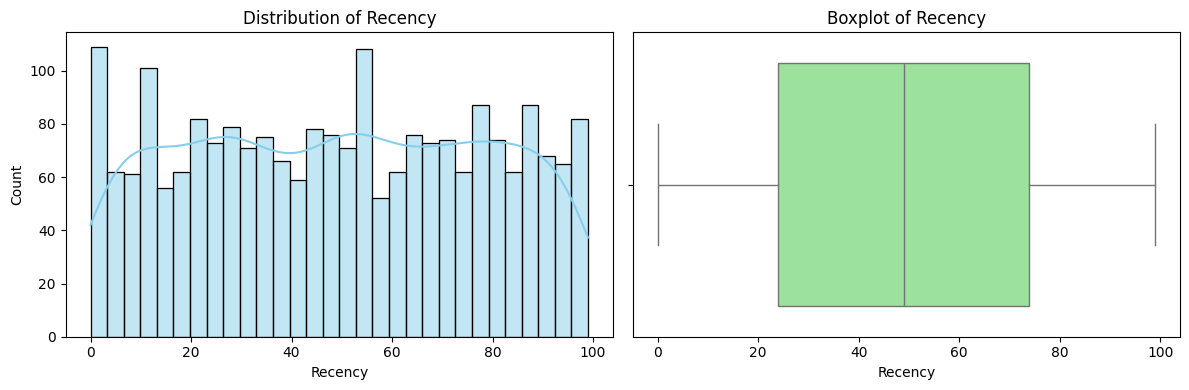

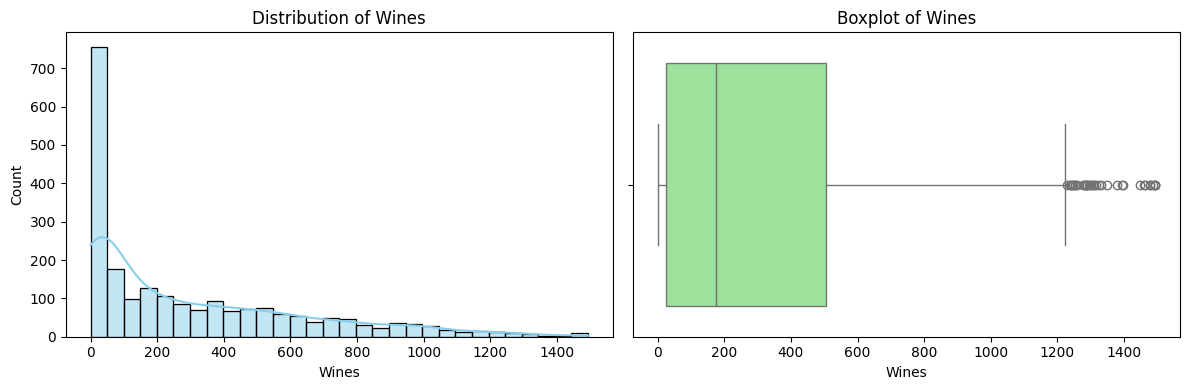

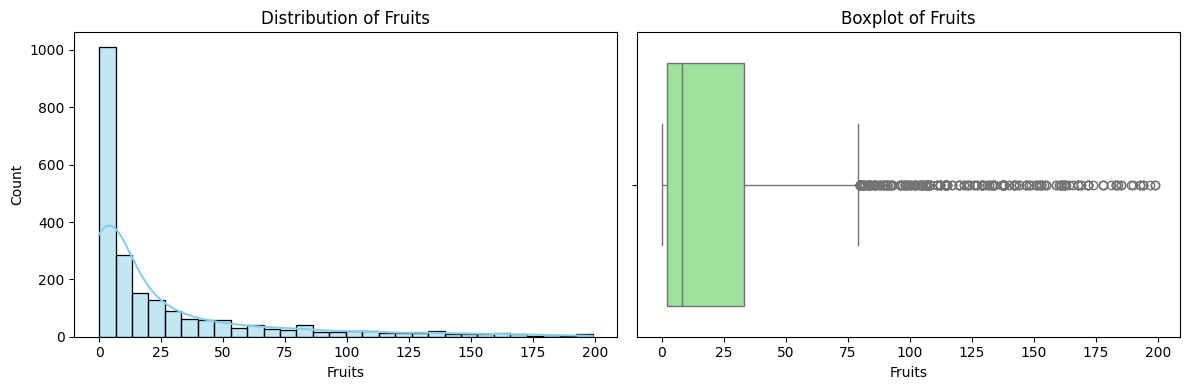

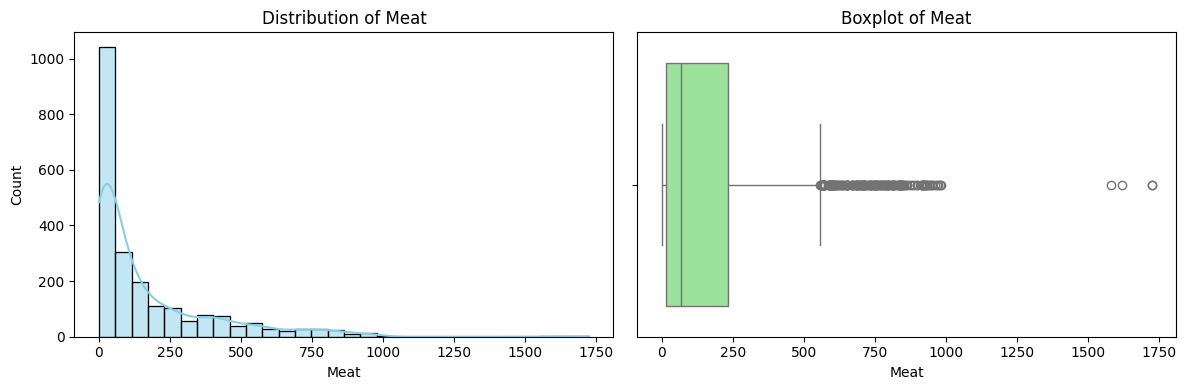

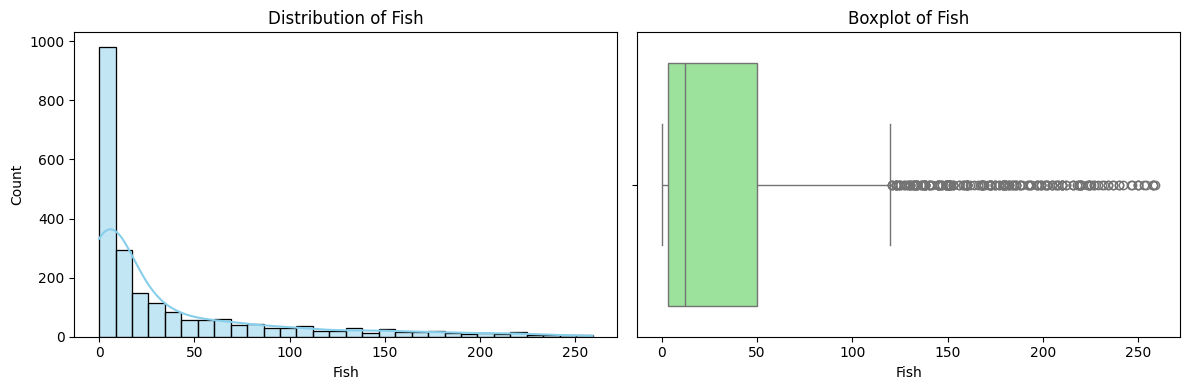

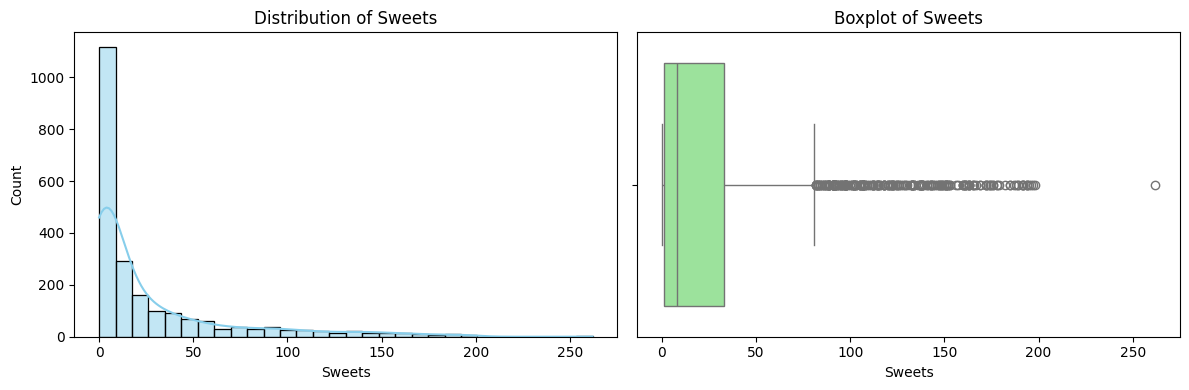

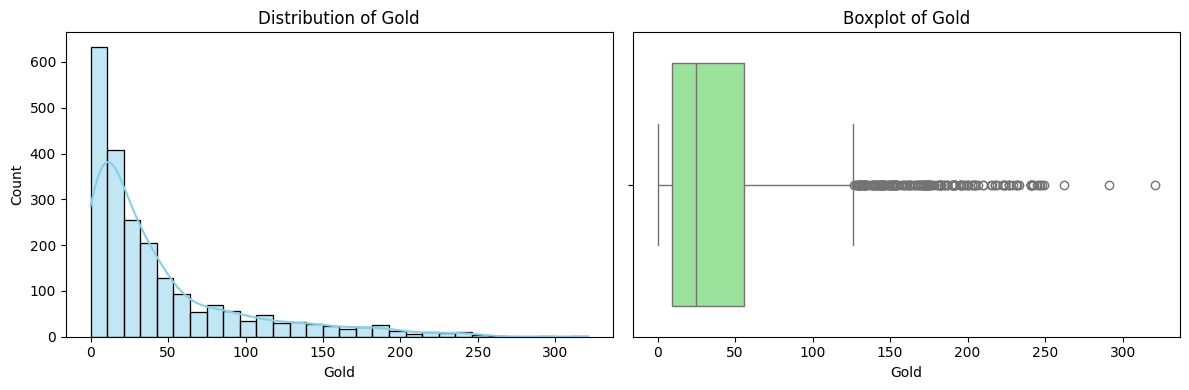

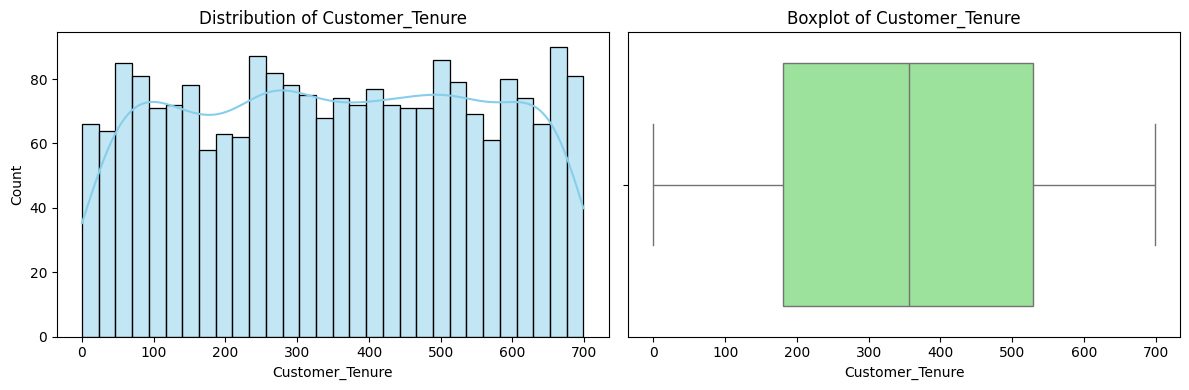

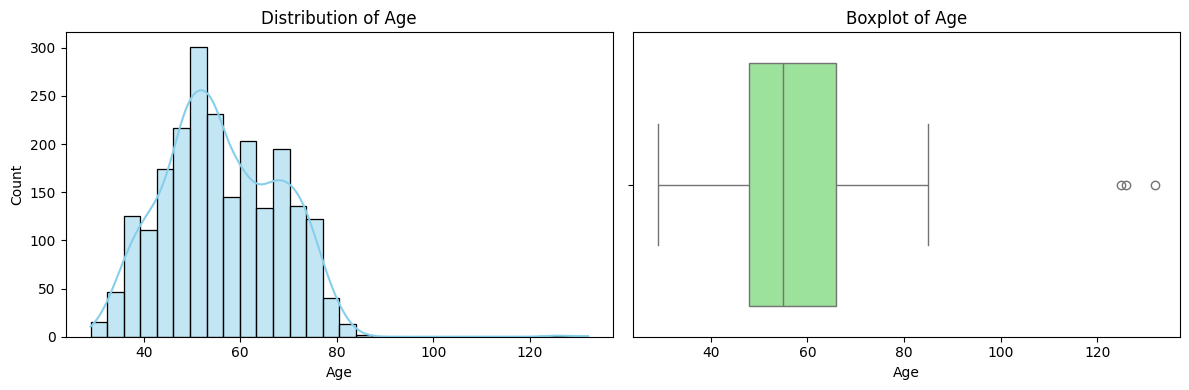

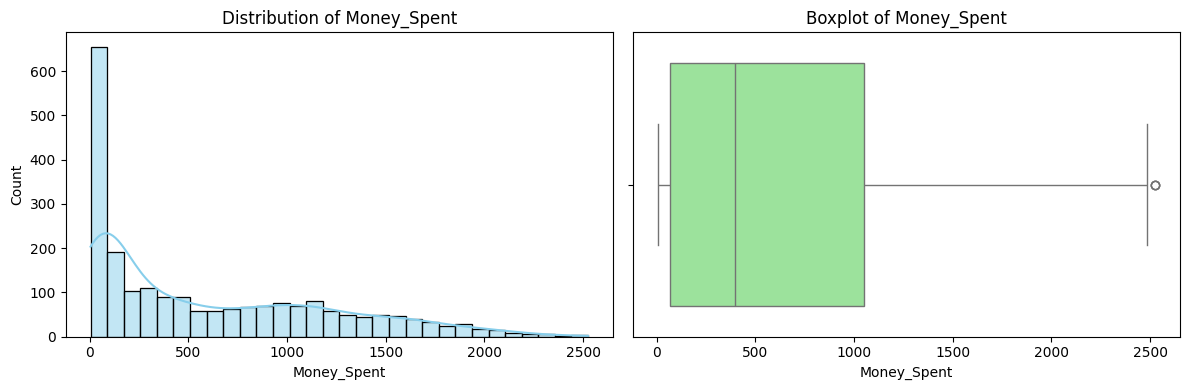

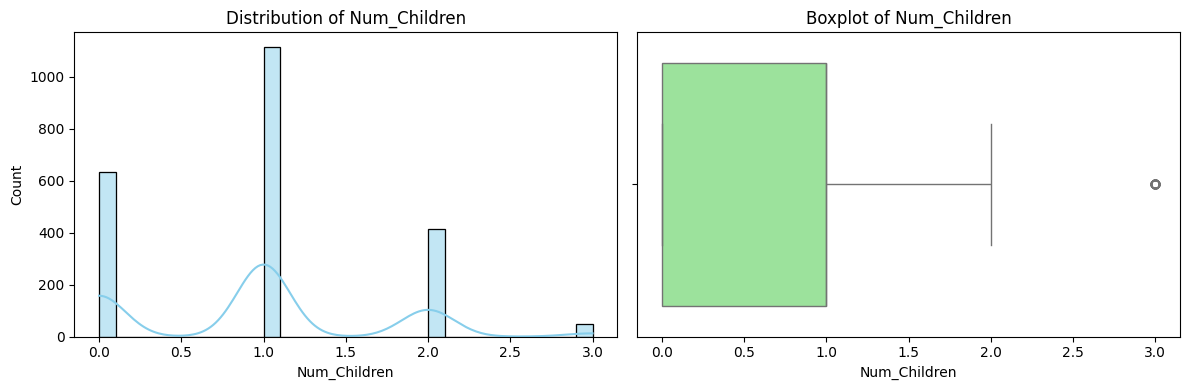

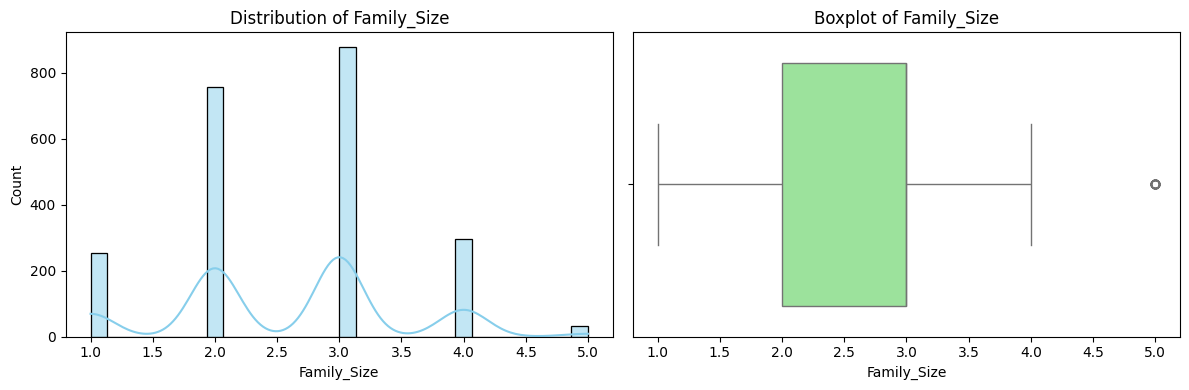

In [349]:
# This line performs: numerical_cols = ["Income", "Recency", "Wines", "Fruits", "M
numerical_cols = ["Income", "Recency", "Wines", "Fruits", "Meat", "Fish",
# This line performs: "Sweets", "Gold", "Customer_Tenure", "Age", "Money_Spent",
                  "Sweets", "Gold", "Customer_Tenure", "Age", "Money_Spent",
# This line performs: "Num_Children", "Family_Size"]
                  "Num_Children", "Family_Size"]

# This line performs: for col in numerical_cols:
for col in numerical_cols:
# This line performs: fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns
    
    # Distribution plot (histogram + KDE)
# This line performs: sns.histplot(r_df[col], kde=True, bins=30, ax=axes[0], color
    sns.histplot(r_df[col], kde=True, bins=30, ax=axes[0], color='skyblue')
# This line performs: axes[0].set_title(f'Distribution of {col}')
    axes[0].set_title(f'Distribution of {col}')
# This line performs: axes[0].set_xlabel(col)
    axes[0].set_xlabel(col)
# This line performs: axes[0].set_ylabel('Count')
    axes[0].set_ylabel('Count')
    
    # Boxplot
# This line performs: sns.boxplot(x=r_df[col], ax=axes[1], color='lightgreen')
    sns.boxplot(x=r_df[col], ax=axes[1], color='lightgreen')
# This line performs: axes[1].set_title(f'Boxplot of {col}')
    axes[1].set_title(f'Boxplot of {col}')
    
# This line performs: plt.tight_layout()
    plt.tight_layout()
# This line performs: plt.show()
    plt.show()

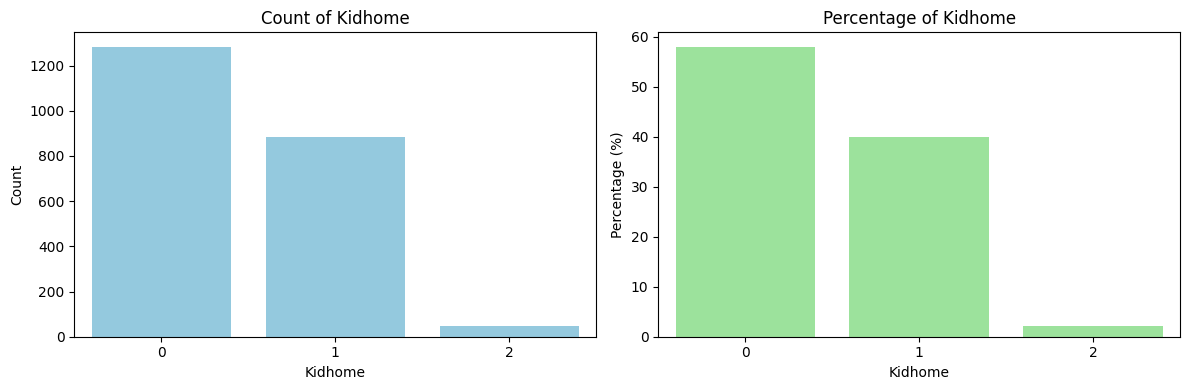

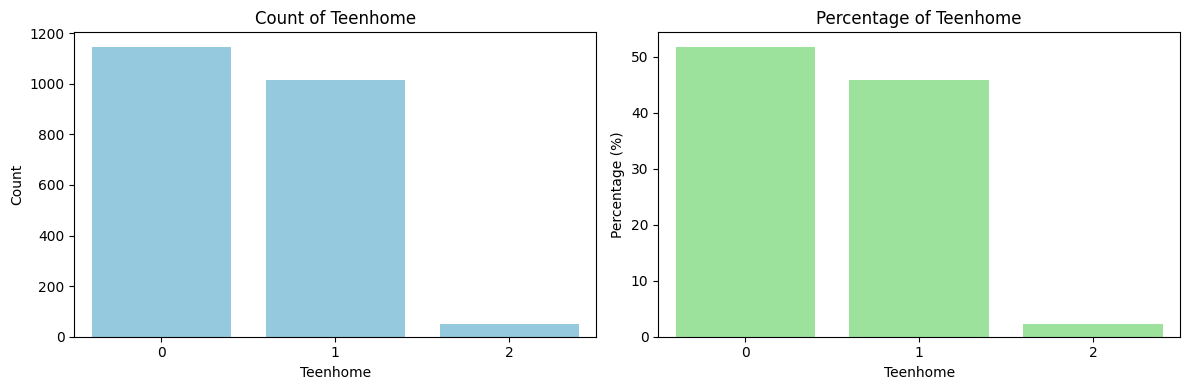

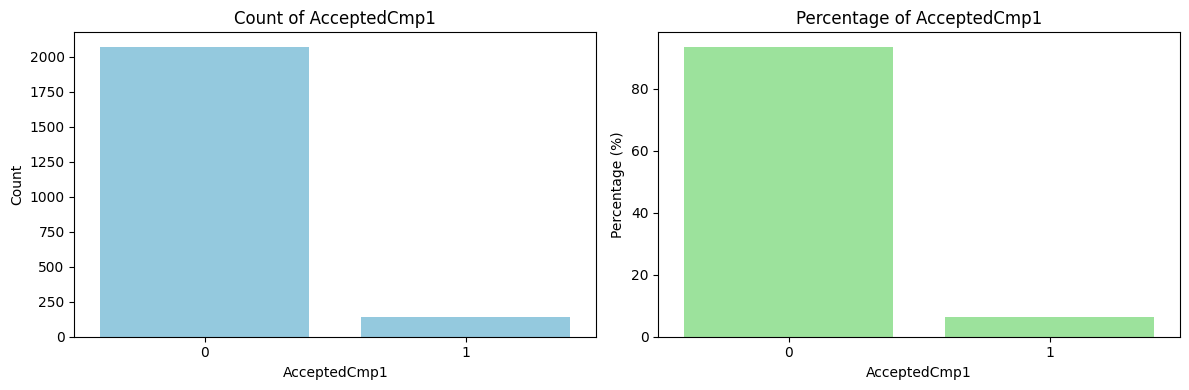

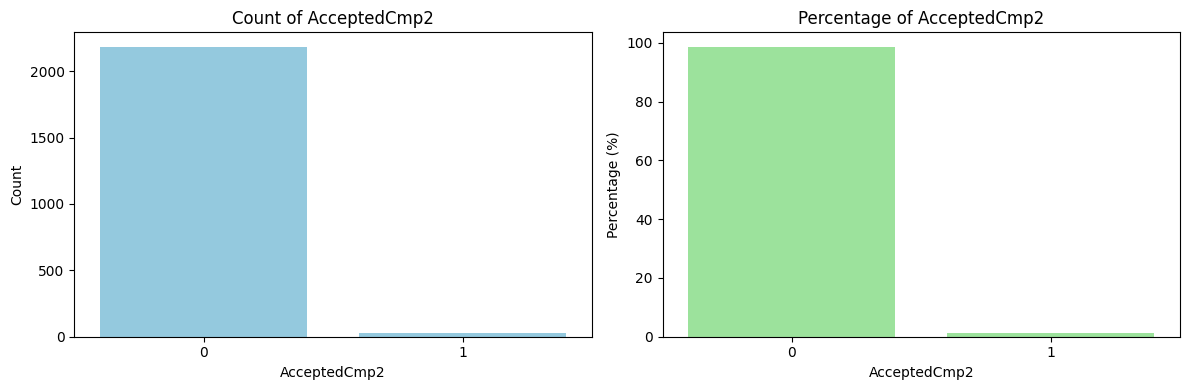

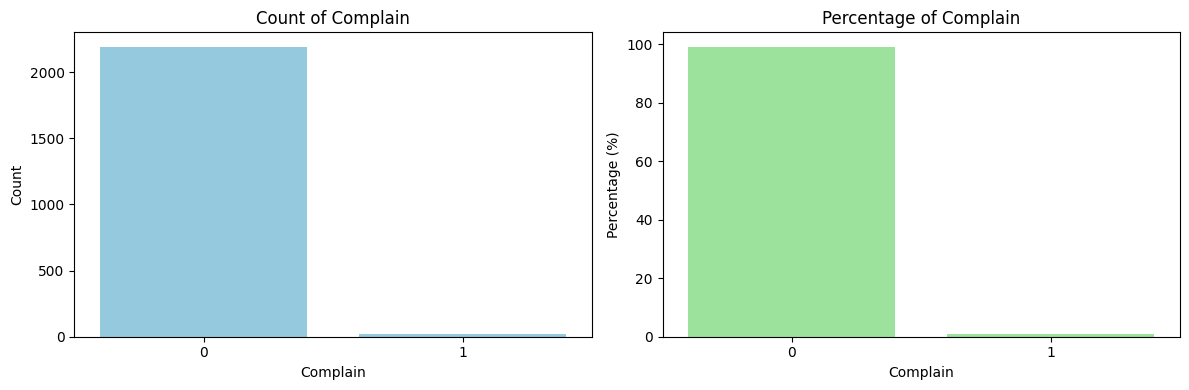

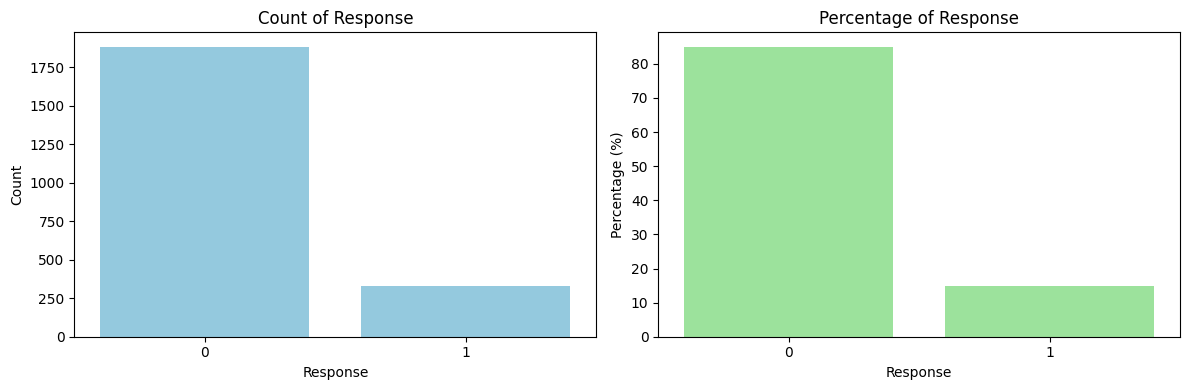

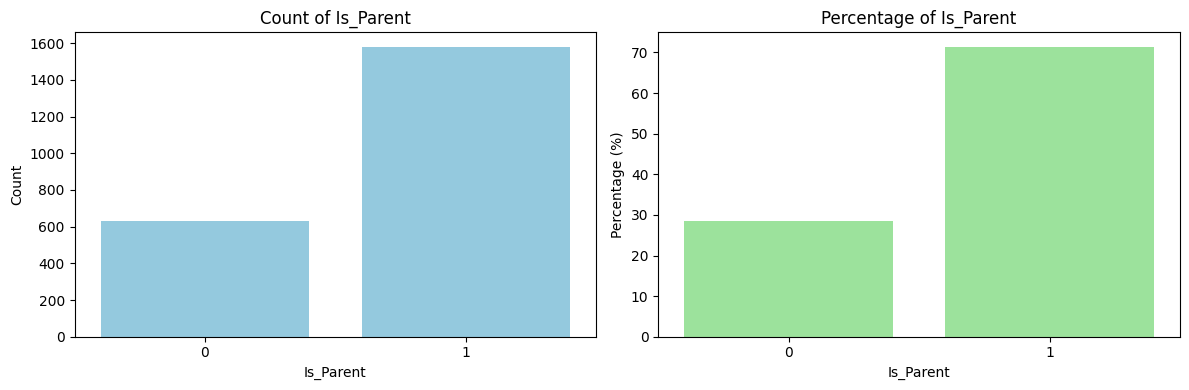

In [350]:
# This line performs: categorical_cols = ["Kidhome", "Teenhome", "AcceptedCmp1",
categorical_cols = ["Kidhome", "Teenhome", "AcceptedCmp1", 
# This line performs: "AcceptedCmp2", "Complain", "Response", "Is_Parent"]
                    "AcceptedCmp2", "Complain", "Response", "Is_Parent"]

# This line performs: for col in categorical_cols:
for col in categorical_cols:
# This line performs: fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Count plot (use color instead of palette)
# This line performs: sns.countplot(x=r_df[col], ax=axes[0], color="skyblue")
    sns.countplot(x=r_df[col], ax=axes[0], color="skyblue")
# This line performs: axes[0].set_title(f'Count of {col}')
    axes[0].set_title(f'Count of {col}')
# This line performs: axes[0].set_xlabel(col)
    axes[0].set_xlabel(col)
# This line performs: axes[0].set_ylabel('Count')
    axes[0].set_ylabel('Count')
    
    # Percentage plot (use color instead of palette)
# This line performs: value_counts = r_df[col].value_counts(normalize=True) * 100
    value_counts = r_df[col].value_counts(normalize=True) * 100
# This line performs: sns.barplot(x=value_counts.index, target=value_counts.values
    sns.barplot(x=value_counts.index, target=value_counts.values, ax=axes[1], color="lightgreen")
# This line performs: axes[1].set_title(f'Percentage of {col}')
    axes[1].set_title(f'Percentage of {col}')
# This line performs: axes[1].set_xlabel(col)
    axes[1].set_xlabel(col)
# This line performs: axes[1].set_ylabel('Percentage (%)')
    axes[1].set_ylabel('Percentage (%)')
    
# This line performs: plt.tight_layout()
    plt.tight_layout()
# This line performs: plt.show()
    plt.show()

In [351]:
# Removing outliers by capping Age 90 and Income 600000
# This line performs: r_df = r_df[(r_df["Age"] < 90) & (r_df["Income"] < 600000)]
r_df = r_df[(r_df["Age"] < 90) & (r_df["Income"] < 600000)]

# This line performs: print("The total number of data points after removing the ou
print("The total number of data points after removing the outliers are:", len(r_df))

The total number of data points after removing the outliers are: 2209


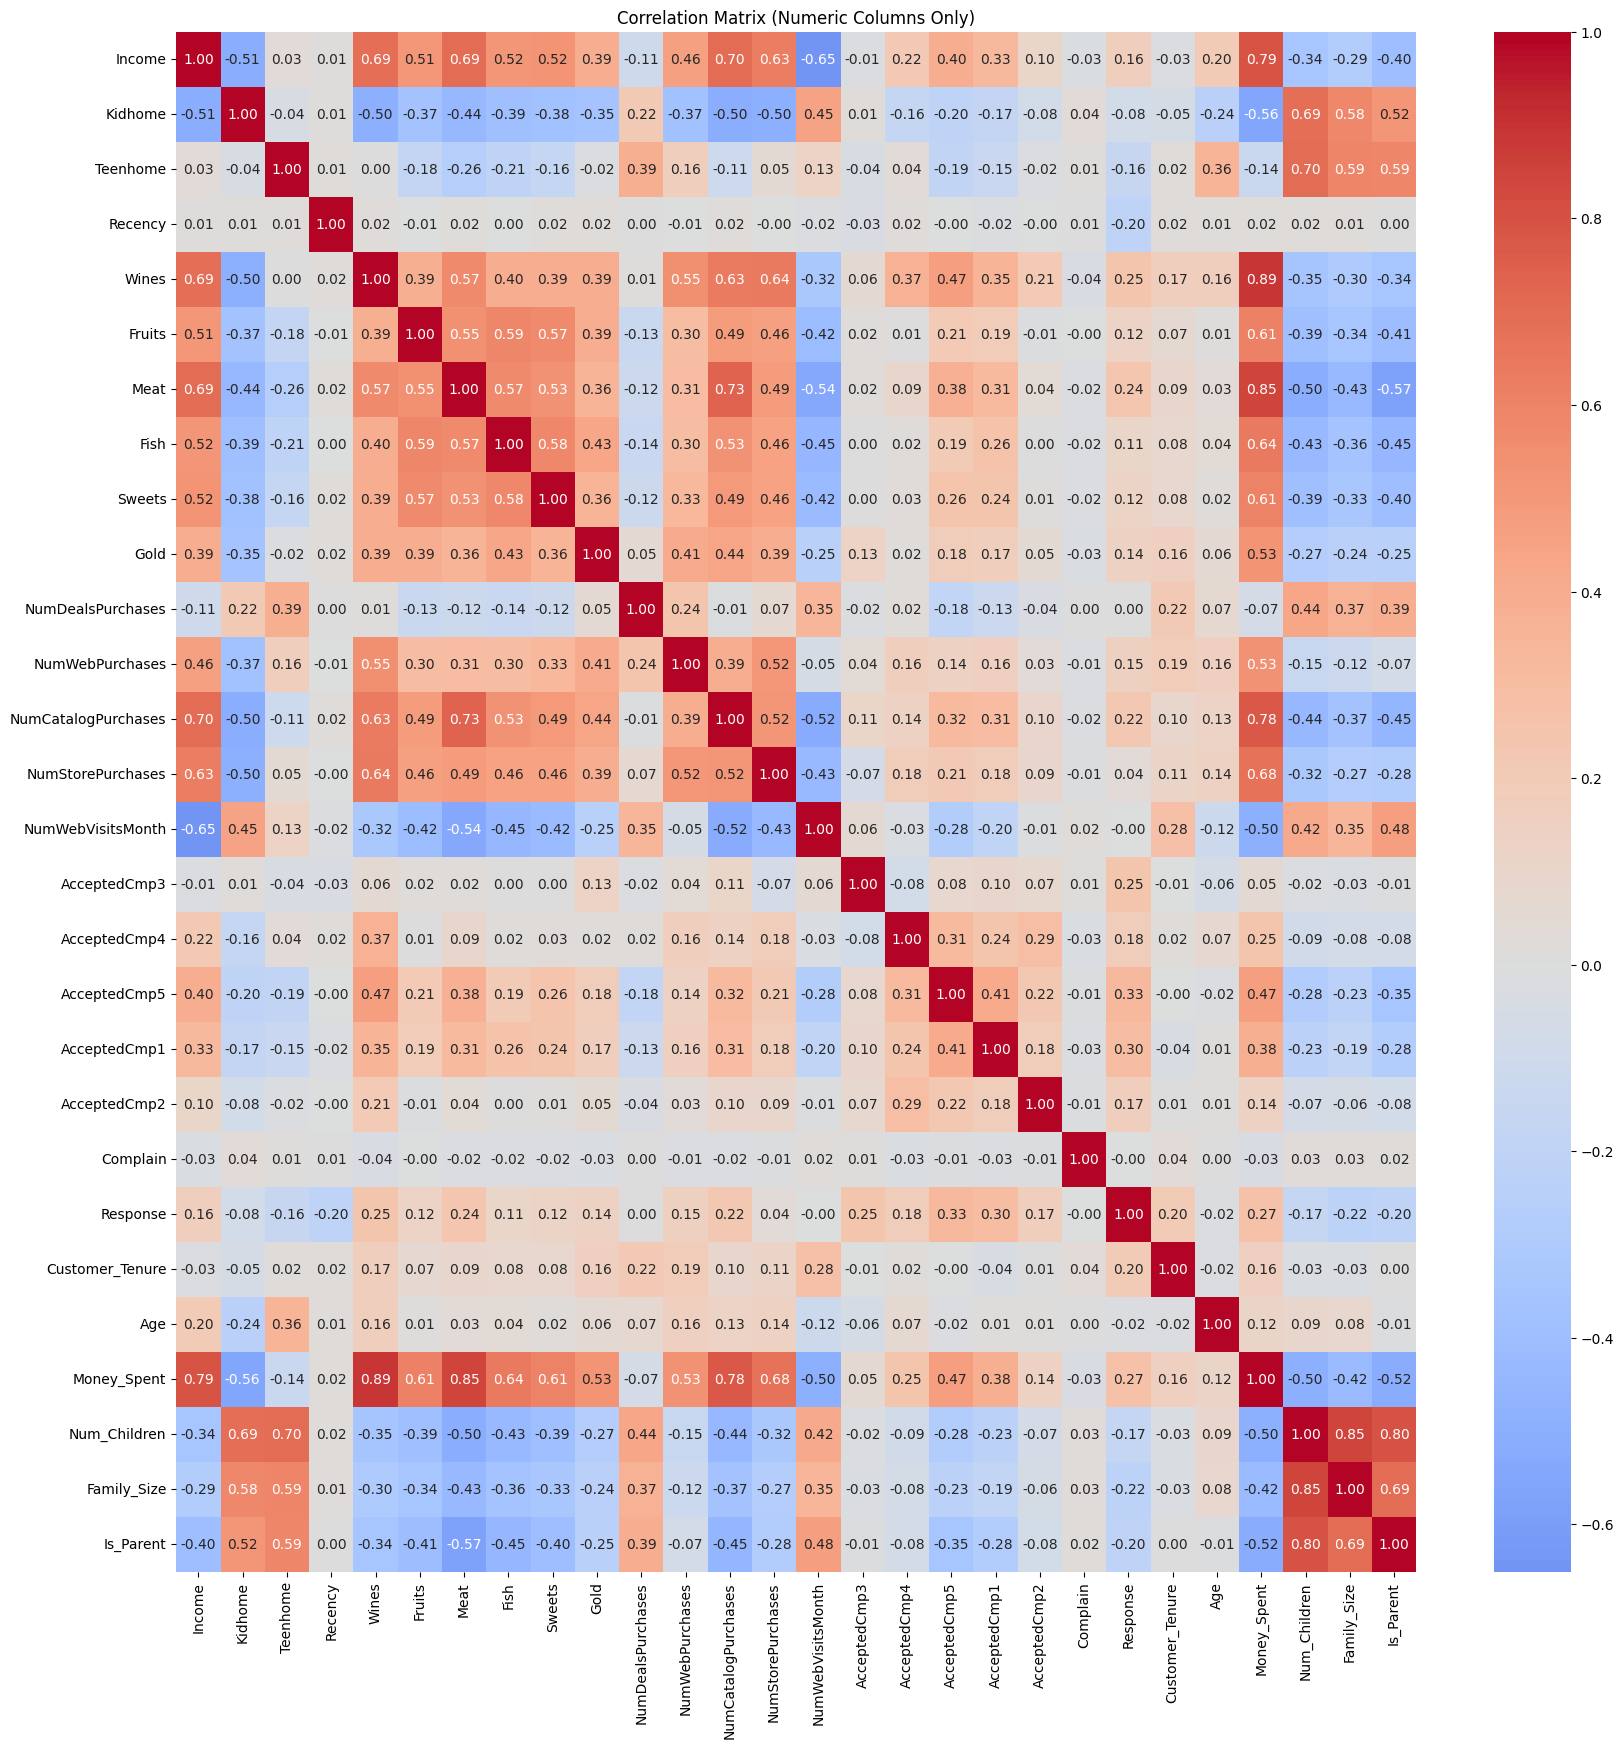

In [352]:
# Compute correlation matrix
# This line performs: numeric_data = r_df.select_dtypes(include=['int64', 'float64
numeric_data = r_df.select_dtypes(include=['int64', 'float64'])
# This line performs: corrmat = numeric_data.corr()
corrmat = numeric_data.corr()

# This line performs: plt.figure(figsize=(20,20))
plt.figure(figsize=(20,20))
# This line performs: sns.heatmap(corrmat, annot=True, fmt=".2f", cmap="coolwarm",
sns.heatmap(corrmat, annot=True, fmt=".2f", cmap="coolwarm", center=0)
# This line performs: plt.title("Correlation Matrix (Numeric Columns Only)")
plt.title("Correlation Matrix (Numeric Columns Only)")
# This line performs: plt.show()
plt.show()

Data Preprocessing

In [353]:
# Step 1 Label encoding the categorical features

# This line performs: cat_Var= (r_df.dtypes == 'object')  # Boolean series: True i
cat_Var= (r_df.dtypes == 'object')  # Boolean series: True if dtype is object
# This line performs: object_cols = list(cat_Var[cat_Var].index) # Select only Tru
object_cols = list(cat_Var[cat_Var].index) # Select only True values, convert to list

# This line performs: print("Categorical variables in the dataset:", object_cols)
print("Categorical variables in the dataset:", object_cols)


Categorical variables in the dataset: ['Education', 'Living_With']


In [354]:

# Label Encodee

# This line performs: for col in object_cols:
for col in object_cols:
# This line performs: le = LabelEncoder()
    le = LabelEncoder()
# This line performs: r_df[col] = le.fit_transform(r_df[col])
    r_df[col] = le.fit_transform(r_df[col])

# This line performs: print("All categorical features have been label encoded")
print("All categorical features have been label encoded")

All categorical features have been label encoded


In [355]:
# Copying data to new dataframe

# This line performs: f_df = r_df.copy()
f_df = r_df.copy()


In [356]:
# Dropping AcceptedCmp3, AcceptedCmp4, AcceptedCmp5, AcceptedCmp1, AcceptedCmp2, Complain, Response columns

# This line performs: f_df = f_df.drop(columns=['AcceptedCmp3', 'AcceptedCmp4', 'A
f_df = f_df.drop(columns=['AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 
# This line performs: 'AcceptedCmp1','AcceptedCmp2', 'Complain', 'Response'])
                          'AcceptedCmp1','AcceptedCmp2', 'Complain', 'Response'])


In [357]:
#Scaling the features using standard scaler

# This line performs: scaler = StandardScaler()
scaler = StandardScaler()
# This line performs: scaled_f_df = pd.DataFrame(scaler.fit_transform(f_df), colum
scaled_f_df = pd.DataFrame(scaler.fit_transform(f_df), columns=f_df.columns)
# This line performs: print("All features are now scaled")
print("All features are now scaled")



All features are now scaled


In [358]:
# Scaled data to be used for reducing the dimensionality
# This line performs: print("Dataframe to be used for modelling:")
print("Dataframe to be used for modelling:")
# This line performs: scaled_f_df.head()
scaled_f_df.head()

Dataframe to be used for modelling:


,Education,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweets,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Customer_Tenure,Age,Money_Spent,Living_With,Num_Children,Family_Size,Is_Parent
0,-0.89316,0.286488,-0.821387,-0.929195,0.309397,0.976952,1.550563,1.688752,2.451601,1.482299,...,2.501821,-0.556404,0.692483,1.527315,1.018028,1.674925,-1.352193,-1.263568,-1.757386,-1.579637
1,-0.89316,-0.261305,1.041492,0.908398,-0.381593,-0.872905,-0.637931,-0.718789,-0.651448,-0.634360,...,-0.572074,-1.171567,-0.131928,-1.190669,1.274500,-0.963783,-1.352193,1.406180,0.448960,0.633057
2,-0.89316,0.912357,-0.821387,-0.929195,-0.796187,0.357368,0.569514,-0.179321,1.338154,-0.147772,...,-0.230531,1.289085,-0.544134,-0.207253,0.334105,0.279231,0.739540,-1.263568,-0.654213,-1.579637
3,-0.89316,-1.176212,1.041492,-0.929195,-0.796187,-0.872905,-0.562465,-0.656371,-0.505422,-0.585701,...,-0.913618,-0.556404,0.280278,-1.062183,-1.290212,-0.920634,0.739540,0.071306,0.448960,0.633057
4,0.57157,0.293687,1.041492,-0.929195,1.553179,-0.392654,0.418584,-0.219447,0.151694,-0.001795,...,0.111013,0.058759,-0.131928,-0.953463,-1.033741,-0.308255,0.739540,0.071306,0.448960,0.633057


In [362]:
# This line performs: pca = PCA(n_components=3)
pca = PCA(n_components=3)
# This line performs: PCA_ds = pd.DataFrame(
PCA_ds = pd.DataFrame(
# This line performs: pca.fit_transform(scaled_f_df),
    pca.fit_transform(scaled_f_df),
# This line performs: columns=['PC1', 'PC2', 'PC3']
    columns=['PC1', 'PC2', 'PC3']
# This line performs: )
)


In [363]:
# This line performs: print("\nExplained Variance Ratio (per component):")
print("\nExplained Variance Ratio (per component):")
# This line performs: print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_)

# This line performs: print("\nTotal Variance Explained:",
print("\nTotal Variance Explained:",
# This line performs: round(sum(pca.explained_variance_ratio_), 3))
      round(sum(pca.explained_variance_ratio_), 3))


Explained Variance Ratio (per component):
[0.36010398 0.12695192 0.06594932]

Total Variance Explained: 0.553


In [364]:
# This line performs: print("\nSummary of PCA dataset:")
print("\nSummary of PCA dataset:")
# This line performs: display(PCA_ds.describe().T)
display(PCA_ds.describe().T)


Summary of PCA dataset:


,count,mean,std,min,25%,50%,75%,max
PC1,2209.0,1.415296e-16,2.878566,-5.979519,-2.542637,-0.776571,2.395897,7.445883
PC2,2209.0,0.000000e+00,1.709157,-4.193872,-1.324738,-0.173269,1.233711,6.166146
PC3,2209.0,3.739275e-17,1.231877,-3.618907,-0.850845,-0.053047,0.862471,6.747736


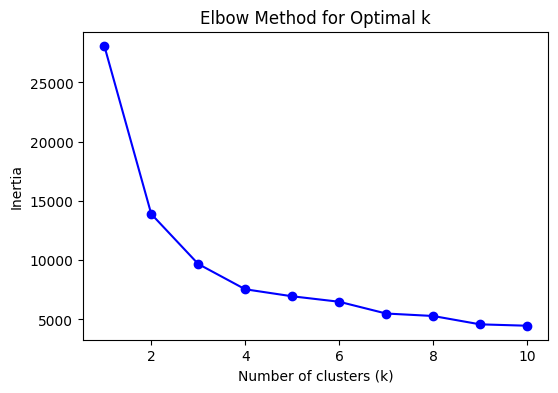

In [365]:
# This line performs: from sklearn.cluster import KMeans
from sklearn.cluster import KMeans
# This line performs: import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

# This line performs: inertia = []
inertia = []
# This line performs: K = range(1, 11)
K = range(1, 11)

# This line performs: for k in K:
for k in K:
# This line performs: kmeans_model = KMeans(n_clusters=k, random_state=42)
    kmeans_model = KMeans(n_clusters=k, random_state=42)
# This line performs: kmeans_model.fit(PCA_ds)
    kmeans_model.fit(PCA_ds)
# This line performs: inertia.append(kmeans_model.inertia_)
    inertia.append(kmeans_model.inertia_)

# This line performs: plt.figure(figsize=(6,4))
plt.figure(figsize=(6,4))
# This line performs: plt.plot(K, inertia, 'bo-')
plt.plot(K, inertia, 'bo-')
# This line performs: plt.xlabel('Number of clusters (k)')
plt.xlabel('Number of clusters (k)')
# This line performs: plt.ylabel('Inertia')
plt.ylabel('Inertia')
# This line performs: plt.title('Elbow Method for Optimal k')
plt.title('Elbow Method for Optimal k')
# This line performs: plt.show()
plt.show()

In [366]:
# This line performs: from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_score

# This line performs: for k in range(2, 11):
for k in range(2, 11):
# This line performs: kmeans_model = KMeans(n_clusters=k, random_state=42)
    kmeans_model = KMeans(n_clusters=k, random_state=42)
# This line performs: labels = kmeans_model.fit_predict(PCA_ds)
    labels = kmeans_model.fit_predict(PCA_ds)
# This line performs: score = silhouette_score(PCA_ds, labels)
    score = silhouette_score(PCA_ds, labels)
# This line performs: print(f"k={k}, Silhouette Score={score:.3f}")
    print(f"k={k}, Silhouette Score={score:.3f}")

k=2, Silhouette Score=0.445
k=3, Silhouette Score=0.411
k=4, Silhouette Score=0.373
k=5, Silhouette Score=0.315
k=6, Silhouette Score=0.260
k=7, Silhouette Score=0.300
k=8, Silhouette Score=0.291
k=9, Silhouette Score=0.309
k=10, Silhouette Score=0.283
